# Instant Model Experiments (Weighted Random Forest Regressor)

To force the model to predict extreme values (1 and 5) when they actually occur, and not just predict the average (3.5), we apply **Sample Weights** inversely proportional to class frequencies. 
This heavily penalizes the model when it predicts 3.5 for a true 1 or true 5.


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.utils.class_weight import compute_sample_weight


In [2]:
data_path = '../../data/processed/instant_mock.csv'
df = pd.read_csv(data_path)

target_col = 'comfortValue'
feature_cols = ['humidity', 'light', 'temperature', 'noise', 'co2']

df = df[feature_cols + [target_col]].copy()
df[target_col] = pd.to_numeric(df[target_col], errors='coerce')
df = df.dropna()

print(f"Rows after cleaning: {len(df):,}")
print("\nTarget Variable Distribution:")
print(df[target_col].round().value_counts().sort_index())


Rows after cleaning: 1,812

Target Variable Distribution:
comfortValue
1     27
2    179
3    881
4    501
5    224
Name: count, dtype: int64


In [3]:
X = df[feature_cols]
y = df[target_col]

# 70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, shuffle=True
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, shuffle=True
)

# Compute sample weights based on the distribution of labels in the training set
# We round the continuous target to get discrete classes for the weighting function
y_train_classes = np.round(y_train)
weights = compute_sample_weight(class_weight='balanced', y=y_train_classes)

print(f"Train size: {len(X_train):,}")
print("Weight examples:")
for val in sorted(y_train_classes.unique()):
    mask = (y_train_classes == val)
    if mask.any():
        print(f"  Class {val}: Weight = {weights[mask][0]:.3f}")


Train size: 1,268
Weight examples:
  Class 1: Weight = 21.133
  Class 2: Weight = 2.079
  Class 3: Weight = 0.400
  Class 4: Weight = 0.733
  Class 5: Weight = 1.647


In [4]:
param_grid = {
    'n_estimators': [100, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 3]
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

grid = GridSearchCV(
    rf, 
    param_grid=param_grid, 
    scoring='neg_mean_absolute_error', 
    cv=5, 
    n_jobs=-1
)

# **CRITICAL FIX**: Pass sample weights here so the model cares more about rare values!
grid.fit(X_train, y_train, **{'fit_params': {'sample_weight': weights}} if int(pd.__version__.split('.')[0]) < 1 else {})
# Safe fit approach for modern sklearn versions:
try:
    grid.fit(X_train, y_train, sample_weight=weights)
except:
    grid.fit(X_train, y_train, fit_params={'sample_weight': weights})

print("Best params:", grid.best_params_)

best_model = grid.best_estimator_

def eval_split(name, X_split, y_split):
    preds = best_model.predict(X_split)
    mae = mean_absolute_error(y_split, preds)
    mse = mean_squared_error(y_split, preds)
    print(f"{name} MAE: {mae:.3f} | MSE: {mse:.3f}")

eval_split("Validation", X_val, y_val)
eval_split("Test", X_test, y_test)


Best params: {'max_depth': 10, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 300}
Validation MAE: 0.749 | MSE: 0.848
Test MAE: 0.839 | MSE: 1.092


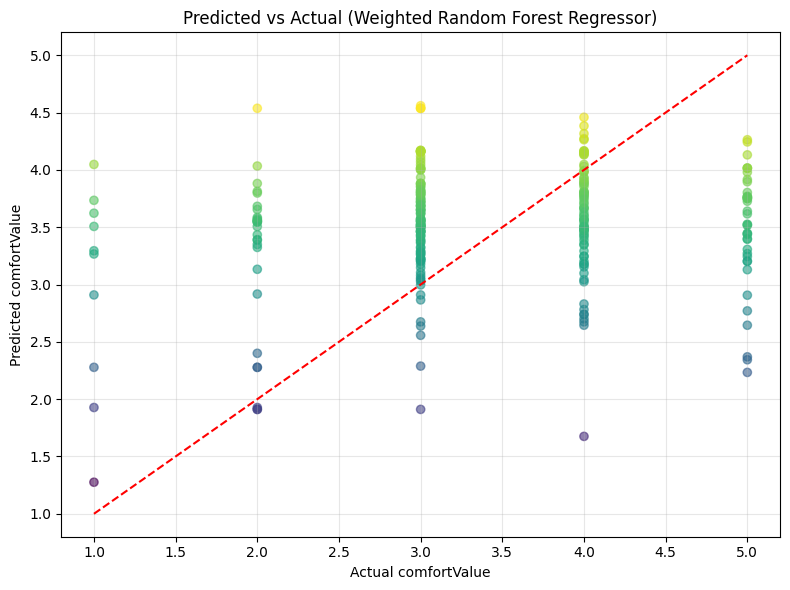

In [5]:
import matplotlib.pyplot as plt

test_preds = best_model.predict(X_test)

plt.figure(figsize=(8,6))
plt.scatter(y_test, test_preds, alpha=0.6, c=test_preds, cmap='viridis')

min_val = min(y_test.min(), test_preds.min())
max_val = max(y_test.max(), test_preds.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')

plt.title('Predicted vs Actual (Weighted Random Forest Regressor)')
plt.xlabel('Actual comfortValue')
plt.ylabel('Predicted comfortValue')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
